In [1]:
import utils
import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import pandas as pd

In [2]:
(train_x, train_y), (test_x, test_y) = utils.read_gate_one_data()

datasett\Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg /data/upload/3/c94577a6-Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg
datasett\275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg /data/upload/3/bb413a1b-275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg
datasett\black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg /data/upload/3/e82f4a47-black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg
datasett\kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png /data/upload/3/5e846c95-kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png


(3684, 300, 300, 3)
(3684,)
(651, 300, 300, 3)
(651,)
[1 0 0 ... 1 1 0]


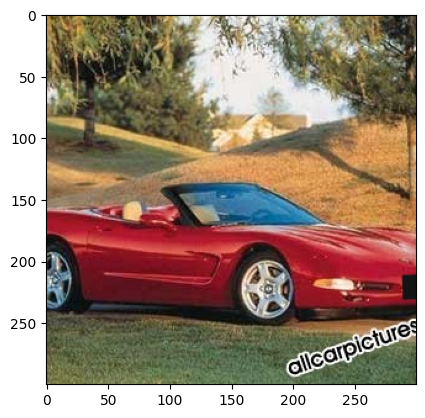

In [3]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

i = 93
print(train_y)
plt.imshow(train_x[i])
plt.show()

In [4]:
i = 0

1


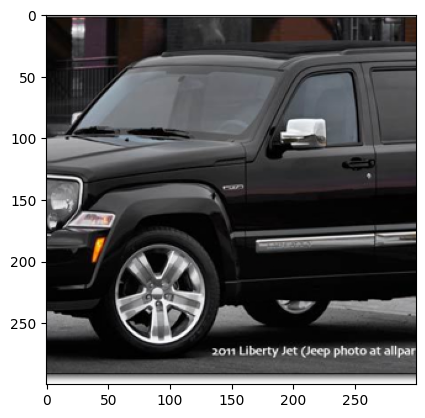

In [5]:

print(train_y[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [6]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y,
    epochs=epochs,
)

Epoch 1/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 94s 803ms/step - accuracy: 0.6846 - loss: 0.6170
Epoch 2/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 94s 813ms/step - accuracy: 0.8016 - loss: 0.4404
Epoch 3/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 95s 816ms/step - accuracy: 0.8507 - loss: 0.3497
Epoch 4/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 92s 789ms/step - accuracy: 0.8868 - loss: 0.2729
Epoch 5/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 89s 769ms/step - accuracy: 0.9368 - loss: 0.1796


In [7]:
functional_model.evaluate(test_x, test_y)

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.8080 - loss: 0.4291


[0.4290805160999298, 0.8079876899719238]

['Dark-Other car--Orange', 'Light-S-2021–nå-Light gray/Silver']<br>
Mangler orange bil, mørk og Nyeste model S grå/sølv i lys for å kunne stratifisere på 'color'<br>
Har Ekskludert nyeste model X for å kunne stratifisere på 'year'

In [8]:
(train_x, train_y), (test_x, test_y) = utils.read_stratified_data(columns=('lighting', 'model', 'year'), test_size=0.15)

datasett\Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg /data/upload/3/c94577a6-Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg
datasett\kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png /data/upload/3/5e846c95-kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
datasett\275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg /data/upload/3/bb413a1b-275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg


In [9]:
print(train_x.shape)
print(train_y.shape)

print(test_x.shape)
print(test_y.shape)

(3628, 300, 300, 3)
(3628, 10)
(641, 300, 300, 3)
(641, 10)


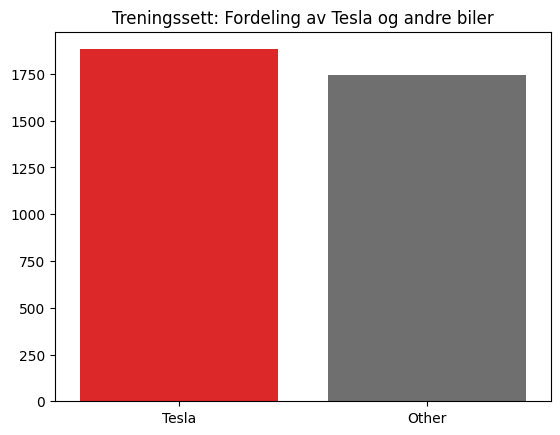

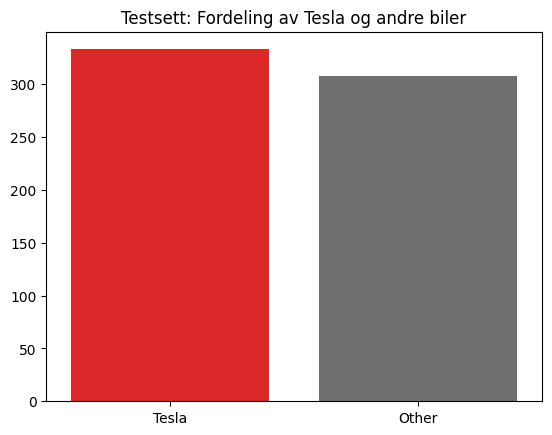

In [10]:
df = train_y
other = 'Other car'

names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Treningssett: Fordeling av Tesla og andre biler')
plt.show()

df = test_y
names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Testsett: Fordeling av Tesla og andre biler')
plt.show()

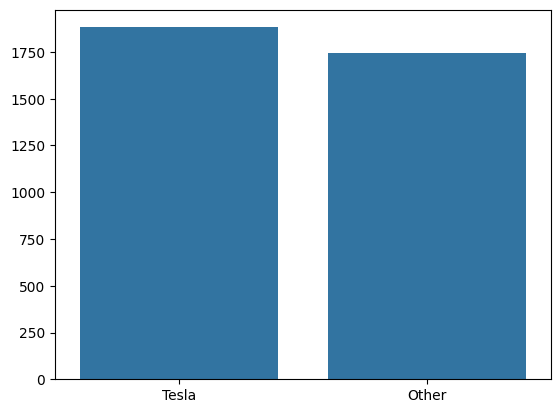

<Axes: >

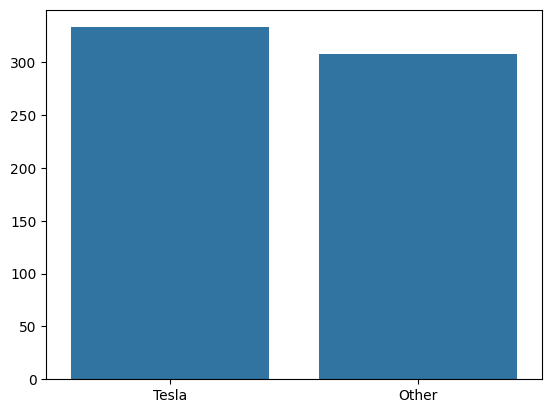

In [11]:
df = train_y
tesla = df[df['model'] != other]
others = df[df['model'] == other]


sns.barplot(data={'Tesla':len(tesla), 'Other': len(others)})
plt.show()

df = test_y
tesla = df[df['model'] != other]
others = df[df['model'] == other]

sns.barplot(data={'Tesla':len(tesla), 'Other': len(others)})

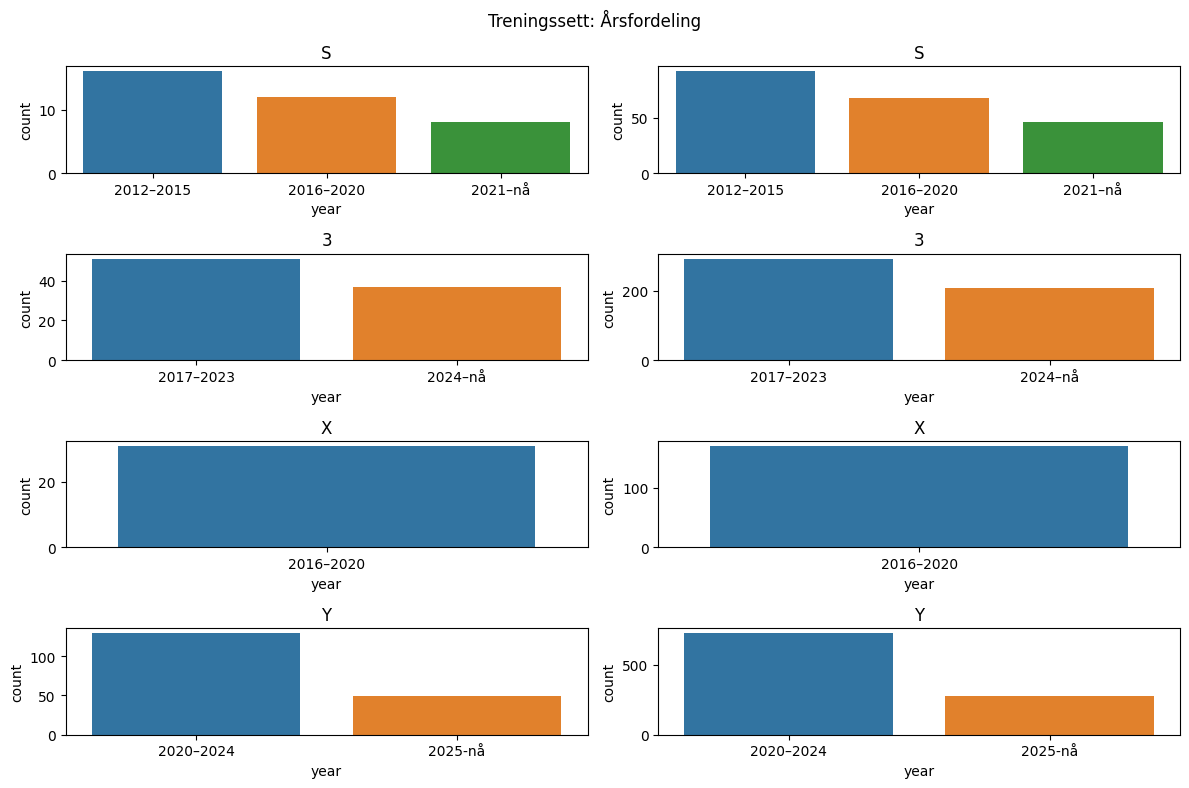

In [ ]:
train_y_split = [
    train_y[train_y['model'] == 'S'].sort_values('year'),
    train_y[train_y['model'] == '3'].sort_values('year'),
    train_y[train_y['model'] == 'X'].sort_values('year'),
    train_y[train_y['model'] == 'Y'].sort_values('year')
]
test_y_split = [
    test_y[test_y['model'] == 'S'].sort_values('year'),
    test_y[test_y['model'] == '3'].sort_values('year'),
    test_y[test_y['model'] == 'X'].sort_values('year'),
    test_y[test_y['model'] == 'Y'].sort_values('year')
]

models = ["S", "3", "X", "Y"]
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
fig.suptitle(f'Trening vs Test splitt')
for i in range(0,2):
    for j in range(0,2):
        sns.countplot(x='year', data=train_y_split[i*2 + j], ax=axes[i*2+j,1], hue='year')
        axes[i*2+j,0].title.set_text(models[i*2 + j])
        sns.countplot(x='year', data=test_y_split[i*2 + j], ax=axes[i*2+j,0], hue='year')
        axes[i*2+j,1].title.set_text(models[i*2 + j])

plt.tight_layout()
plt.show()

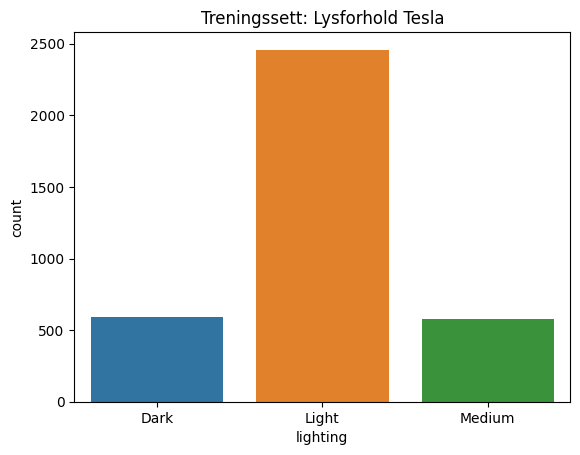

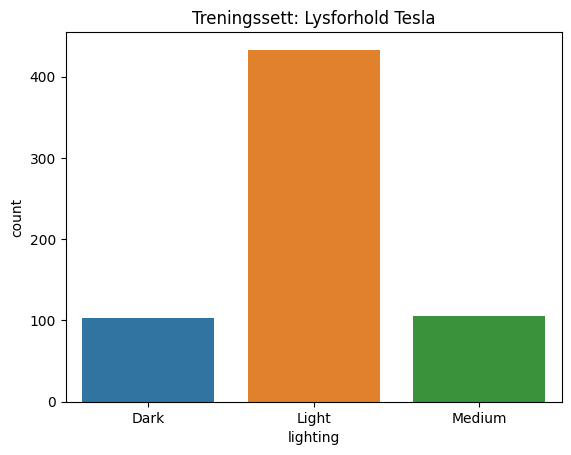

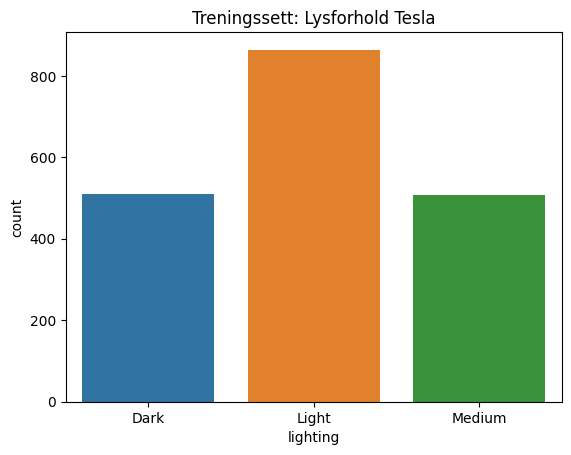

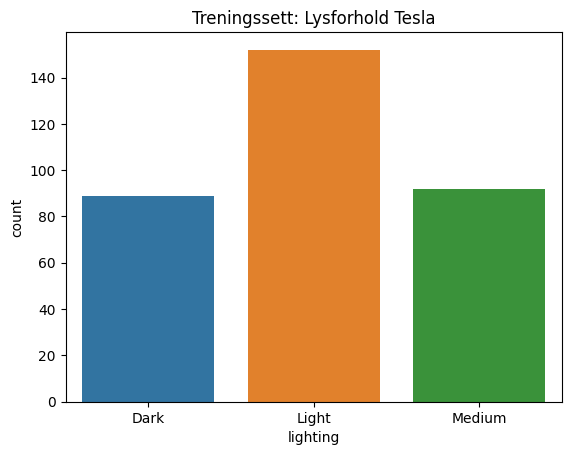

In [20]:
df = train_y.sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()


df = test_y.sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()

df = train_y[train_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()


df = test_y[test_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()